# PCA and k-Means — Wine Quality Exploration

This notebook uses PCA and k-means clustering to explore the Red Wine Quality dataset.

Each row represents a wine sample, and the features describe physicochemical properties of the wine.

## Goals

Walk through an unsupervised learning workflow:

- Load the data
- Scale the features
- Use PCA to reduce the data to two dimensions
- Visualize wine samples in PCA space
- Choose a value of `k` using the elbow method
- Fit a k-means clustering model
- Compare clusters against the true wine quality scores

Evaluate the clustering using:

- PCA explained variance
- Elbow plot
- Silhouette score
- Adjusted Rand Index
- PCA visualization colored by quality
- PCA visualization colored by k-means cluster

Interpret whether the clusters found by k-means align with the true wine quality scores.

## Dataset

- Source: Red Wine Quality dataset
- Size: 1,599 wine samples
- Features: 11 physicochemical measurements:
  - Fixed acidity
  - Volatile acidity
  - Citric acid
  - Residual sugar
  - Chlorides
  - Free sulfur dioxide
  - Total sulfur dioxide
  - Density
  - pH
  - Sulphates
  - Alcohol

## Target

- The `quality` column contains wine quality scores from `3` to `8`.
- Because k-means is unsupervised, the quality labels are not used to train the clustering model.
- The quality labels are only used afterward to evaluate whether the clusters align with true wine quality.

Dataset: 1599 red wine samples, 11 physicochemical features (acidity, sugar, pH, alcohol, etc.). Source: [UCI](https://archive.ics.uci.edu/dataset/186/wine+quality).

In [1]:
import os
import urllib.request

DATA_DIR = (
    os.path.join(os.path.dirname(os.getcwd()), "data")
    if os.path.basename(os.getcwd()) == "notebooks"
    else "data"
)

os.makedirs(DATA_DIR, exist_ok=True)


def download_if_needed(url, filename):
    """Download a CSV if it doesn't already exist locally."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Downloading {filename} from {url}")
        urllib.request.urlretrieve(url, path)
    return path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load data

In [2]:
path = download_if_needed(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-red.csv",
    "wine_quality_red.csv",
)
cols = ["fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
        "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide",
        "density", "pH", "sulphates", "alcohol", "quality"]
df = pd.read_csv(path, header=None, names=cols)
print("Shape:", df.shape)
df.head()

Shape: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print(df.columns)
df.head()

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Scale features (essential for both PCA and k-means)

In [4]:
feat_cols = [c for c in df.columns if c != "quality"]

X = df[feat_cols].values
y = df["quality"].values  # ground-truth quality (we'll only peek at this at the end)

X_s = StandardScaler().fit_transform(X)

## 3. PCA → 2D projection

Variance explained per component: [0.28173931 0.1750827 ]
Cumulative: [0.28173931 0.45682201]


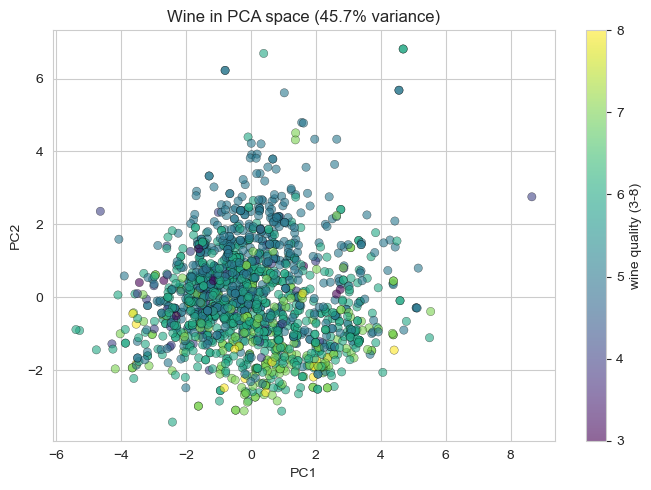

In [5]:
# Project 11-dimensional wine data into 2 dimensions for visualization.
# PCA finds the directions of maximum variance and keeps the top 2.
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_s)


print("Variance explained per component:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.cumsum())

plt.figure(figsize=(7, 5))

sc = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.6,
    edgecolor="k",
    linewidth=0.3,
)

plt.colorbar(sc, label="wine quality (3-8)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Wine in PCA space ({pca.explained_variance_ratio_.sum():.1%} variance)")

plt.tight_layout()
plt.show()

## 4. Choose k via the elbow method

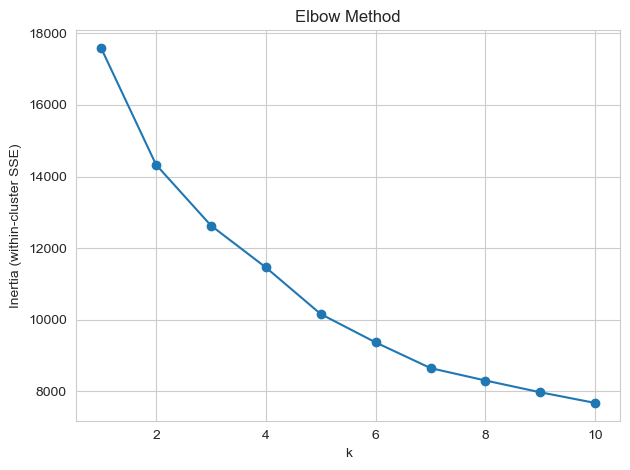

In [6]:
# Elbow method: try k=1..10 and plot within-cluster sum of squares (inertia).
# The "elbow" — where adding more clusters stops dramatically reducing inertia is a heuristic for the right k.
inertias = []
ks = range(1, 11)

for k in ks:
    # n_init=10 runs k-means 10 times with different seeds and keeps the best
    # (k-means is sensitive to initialization)
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_s)
    inertias.append(km.inertia_)

plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method")

plt.tight_layout()
plt.show()

The elbow appears around k=3 or k=4 — the wines naturally cluster into a few groups.

## 5. Fit k-means with k=4

In [7]:
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_s)

clusters = km.labels_

print(f"Silhouette score: {silhouette_score(X_s, clusters):.3f}")
print(f"ARI vs quality:   {adjusted_rand_score(y, clusters):.3f}")


Silhouette score: 0.172
ARI vs quality:   0.063


Note: ARI is low because *quality* (3-8) does not actually cluster cleanly in feature space — wine quality is more nuanced than physicochemistry alone. K-means is finding *real* structure, just not aligned with the quality scores.

## 6. Visualize clusters in PCA space

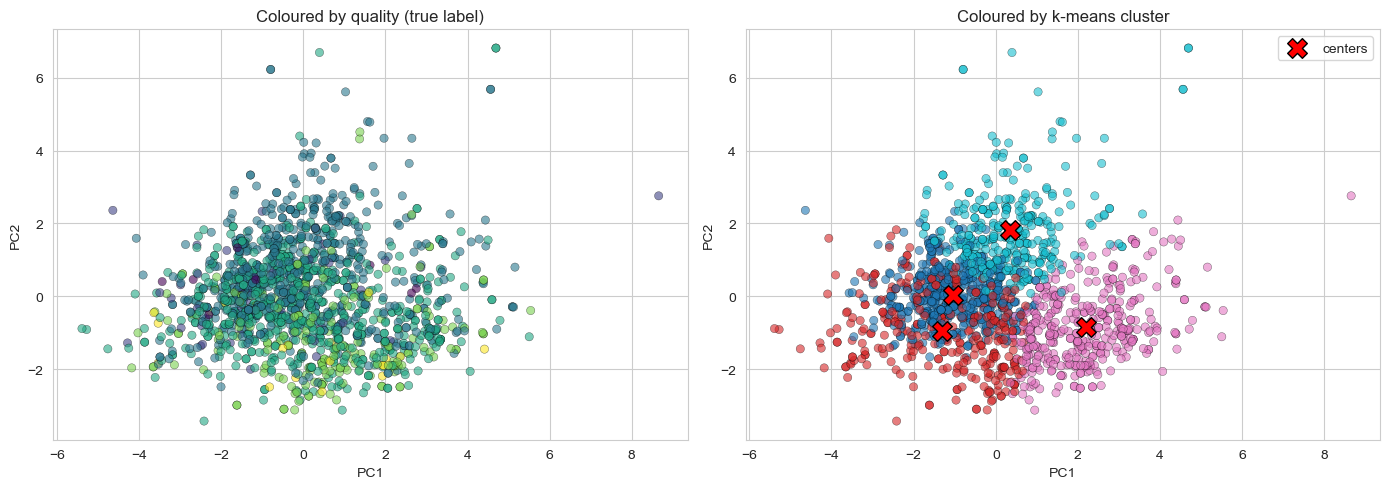

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.6,
    edgecolor="k",
    linewidth=0.3,
)
ax[0].set_title("Coloured by quality (true label)")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

ax[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="tab10",
    alpha=0.6,
    edgecolor="k",
    linewidth=0.3,
)

centers_pca = pca.transform(km.cluster_centers_)
ax[1].scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    s=200,
    marker="X",
    c="red",
    edgecolor="k",
    label="centers",
)

ax[1].set_title("Coloured by k-means cluster")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
ax[1].legend()

plt.tight_layout()
plt.show()

## Takeaways

- The first 2 principal components capture 45.7% of the total variance. This means PCA gives a useful 2D view, but a lot of structure still exists in the remaining dimensions.

- The elbow plot suggests a possible choice around `k = 3` or `k = 4`. In this notebook, we use `k = 4` for the final k-means model.

- The silhouette score is 0.172, which means the clusters are not strongly separated. K-means finds some structure, but the wine samples still overlap heavily in feature space.

- The adjusted Rand index is 0.063, so the k-means clusters do not align closely with the true wine quality scores.

- This makes sense because wine quality is not just a simple cluster label. Wines with similar physicochemical features can still receive different quality scores.

- PCA and k-means together are useful for exploratory analysis: PCA helps visualize high-dimensional data, while k-means gives a simple way to search for possible group structure.